# Recolour ASD augmentation — data-driven domain randomization

Goal: show the **real** recolour ASDs and the **slightly-augmented** versions produced by a
*data-driven* domain-randomization (DR) jitter, and confirm the augmentation stays physical
(a small fraction of the real per-frequency spread).

Method: the jitter gain at each frequency is capped to `k · σ(f)`, where `σ(f)` is the empirical
fractional spread of the real target-run ASD bank — so the perturbation is an interpolation
*within* the real-ASD manifold, never an extrapolation.

**Numerical note:** ASD values are ~1e-24, so their variance (~1e-48) underflows float32
(min-normal 1.2e-38). **σ(f) must be computed in float64** or it silently reads as 0.

In [1]:
%matplotlib inline
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

RUN, DET = "o3a", "H1"          # O3b training recolours toward O3a (this bank)
BASE = f"/work/nagarajan/data_release/{RUN}_dataset/data_dir/recolour_psds"
meta = json.load(open(f"{BASE}/raw_{DET}_psds.json"))
N_ASD, F = meta["num_psds"], meta["num_freq_bins"]
DF = meta["delta_f"]; FLOW = meta["low_frequency_cutoff"]
freq = np.arange(F) * DF
band = (freq >= FLOW) & (freq <= freq.max())
print(f"{RUN} {DET}: {N_ASD} ASDs x {F} bins, df={DF} Hz, band [{FLOW}, {freq.max():.0f}] Hz")

o3a H1: 250000 ASDs x 16385 bins, df=0.0625 Hz, band [15.0, 1024] Hz


## 1. The real recolour ASDs (the *old* set)

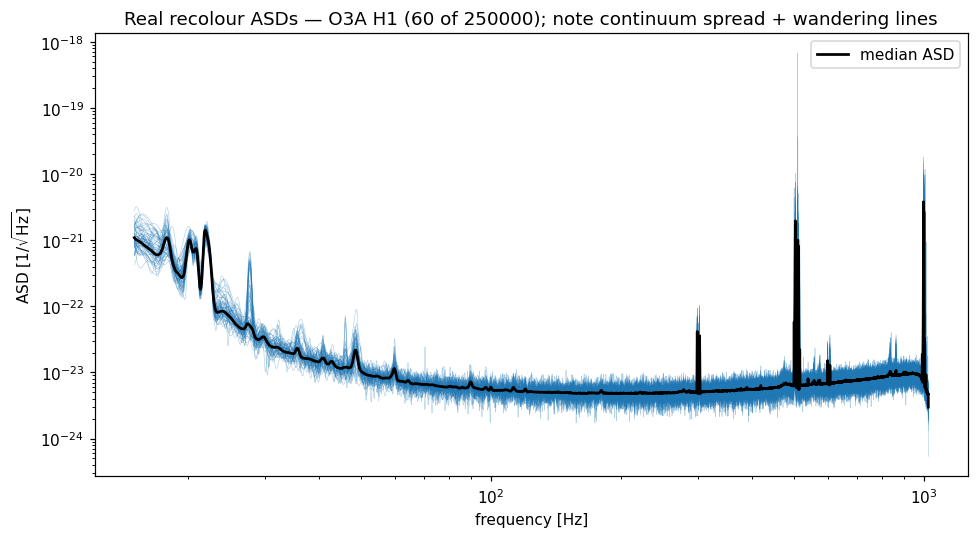

In [2]:
mm = np.memmap(f"{BASE}/raw_{DET}_psds.bin", dtype=np.float32, mode="r", shape=(N_ASD, F))
rng = np.random.default_rng(0)
sample = np.asarray(mm[rng.integers(0, N_ASD, 2000)], dtype=np.float64)   # float64 for stats!

plt.figure()
for r in sample[:60]:
    plt.loglog(freq[band], r[band], lw=0.4, alpha=0.35, color="C0")
plt.loglog(freq[band], np.median(sample, 0)[band], "k", lw=1.8, label="median ASD")
plt.xlabel("frequency [Hz]"); plt.ylabel(r"ASD [1/$\sqrt{\rm Hz}$]")
plt.title(f"Real recolour ASDs — {RUN.upper()} {DET} (60 of {N_ASD}); note continuum spread + wandering lines")
plt.legend(); plt.tight_layout(); plt.show()

## 2. Empirical per-frequency spread σ(f)  (computed in float64)

sigma(f) in-band: median 0.182  90pct 0.237  max 26.96


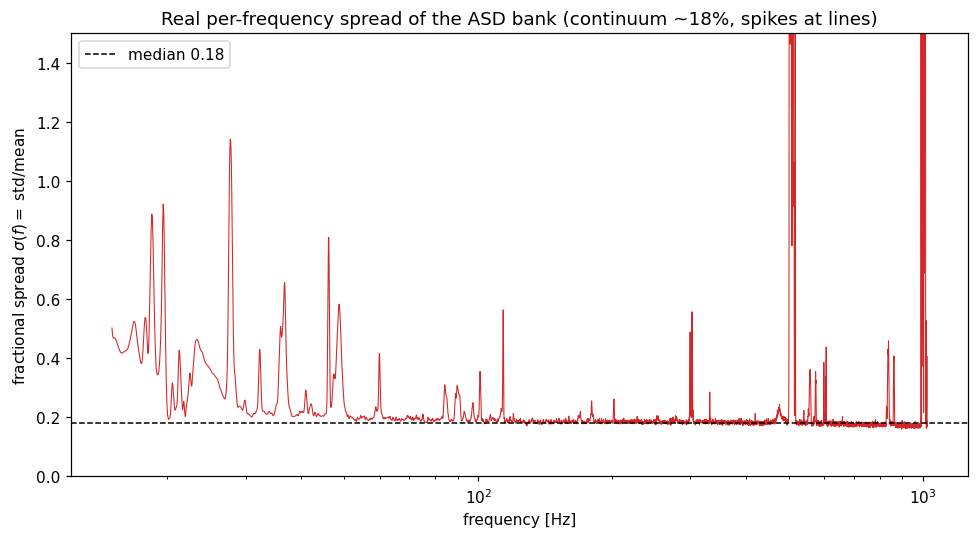

In [3]:
mu = sample.mean(0); sd = sample.std(0)
sigma = sd / (mu + 1e-300)                    # fractional spread per bin
sb = sigma[band]
print(f"sigma(f) in-band: median {np.median(sb):.3f}  90pct {np.percentile(sb,90):.3f}  max {sb.max():.2f}")

plt.figure()
plt.semilogx(freq[band], sigma[band], lw=0.7, color="C3")
plt.axhline(np.median(sb), color="k", ls="--", lw=1, label=f"median {np.median(sb):.2f}")
plt.xlabel("frequency [Hz]"); plt.ylabel(r"fractional spread $\sigma(f)=$ std/mean")
plt.title("Real per-frequency spread of the ASD bank (continuum ~18%, spikes at lines)")
plt.ylim(0, min(1.5, sb.max())); plt.legend(); plt.tight_layout(); plt.show()

## 3. Data-driven augmentation

For each augmented ASD we draw a **smooth** O(1) random shape (broadband + a few low cosine
modes) and scale it, per frequency, by `k · σ(f)`. With `k = 0.3` the continuum jitter is
~0.3 × 18% ≈ 5%, and it is larger only where the real ASDs themselves vary more. A gain clip
is a final safety rail.

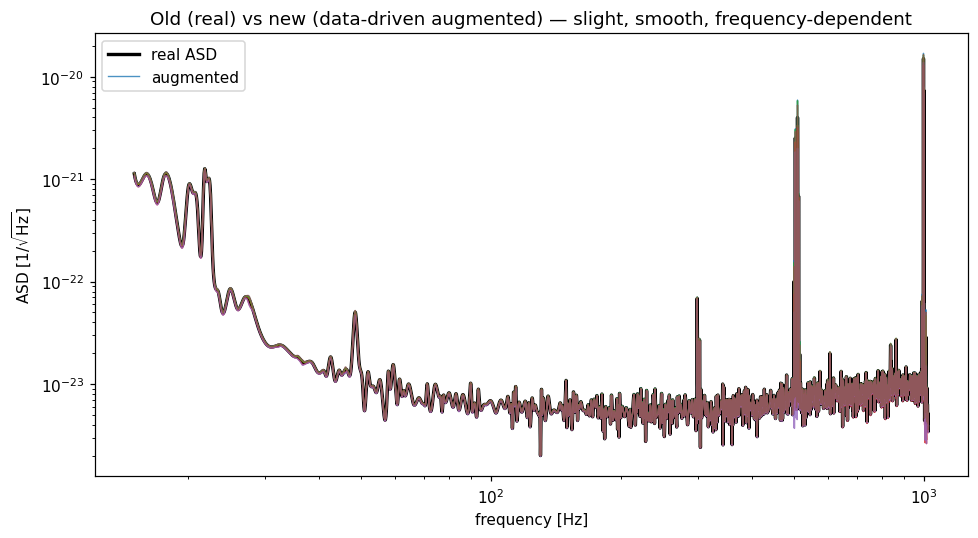

In [4]:
def data_driven_augment(asd, sigma_f, rng, k=0.3, n_modes=4, gclip=(0.5, 2.0)):
    F = len(asd); t = np.linspace(-1, 1, F)
    shape = rng.uniform(-1, 1) * np.ones(F)          # broadband
    for m in range(1, n_modes + 1):                  # smooth low-frequency modes
        shape += rng.uniform(-1, 1) * np.cos(m*np.pi*t + rng.uniform(0, 2*np.pi)) / m
    shape /= (1 + sum(1.0/m for m in range(1, n_modes+1)))   # ~[-1, 1]
    gain = np.clip(1.0 + k * sigma_f * shape, *gclip)
    return asd * gain, gain

base_asd = sample[0]
arng = np.random.default_rng(42)
augs = [data_driven_augment(base_asd, sigma, arng, k=0.3)[0] for _ in range(6)]

plt.figure()
plt.loglog(freq[band], base_asd[band], "k", lw=2.2, label="real ASD")
for i, a in enumerate(augs):
    plt.loglog(freq[band], a[band], lw=0.9, alpha=0.8, label="augmented" if i == 0 else None)
plt.xlabel("frequency [Hz]"); plt.ylabel(r"ASD [1/$\sqrt{\rm Hz}$]")
plt.title("Old (real) vs new (data-driven augmented) — slight, smooth, frequency-dependent")
plt.legend(); plt.tight_layout(); plt.show()

### Zoom on the continuum (30–300 Hz) — the augmentation is a gentle perturbation

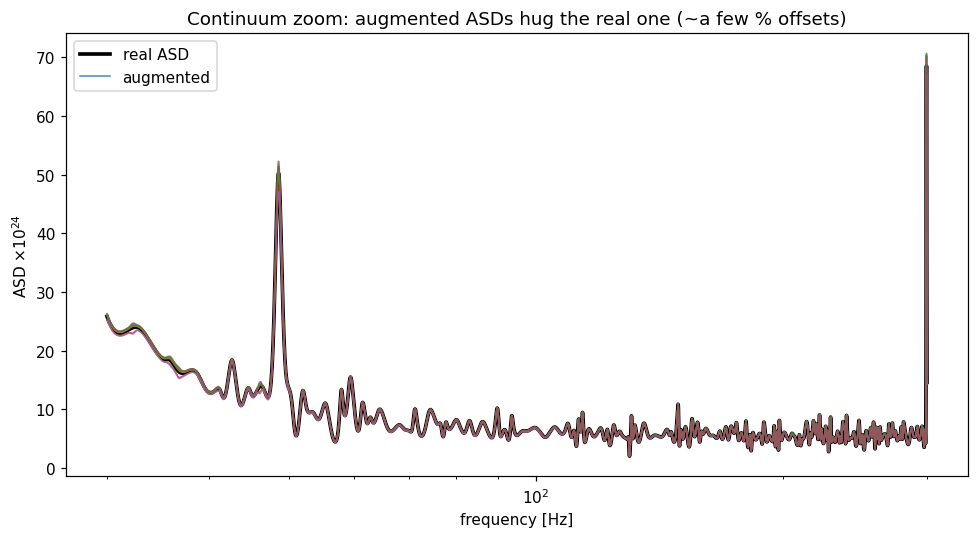

In [5]:
zb = (freq >= 30) & (freq <= 300)
plt.figure()
plt.plot(freq[zb], base_asd[zb]*1e24, "k", lw=2.4, label="real ASD")
for i, a in enumerate(augs):
    plt.plot(freq[zb], a[zb]*1e24, lw=1.0, alpha=0.85, label="augmented" if i == 0 else None)
plt.xlabel("frequency [Hz]"); plt.ylabel(r"ASD $\times 10^{24}$"); plt.xscale("log")
plt.title("Continuum zoom: augmented ASDs hug the real one (~a few % offsets)")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Physicality check — augmented ASDs stay inside the real spread envelope

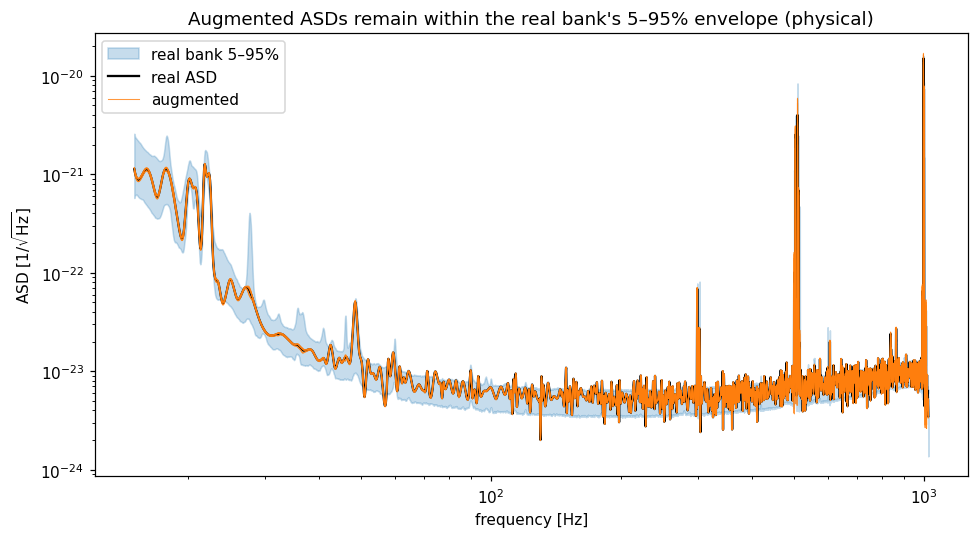

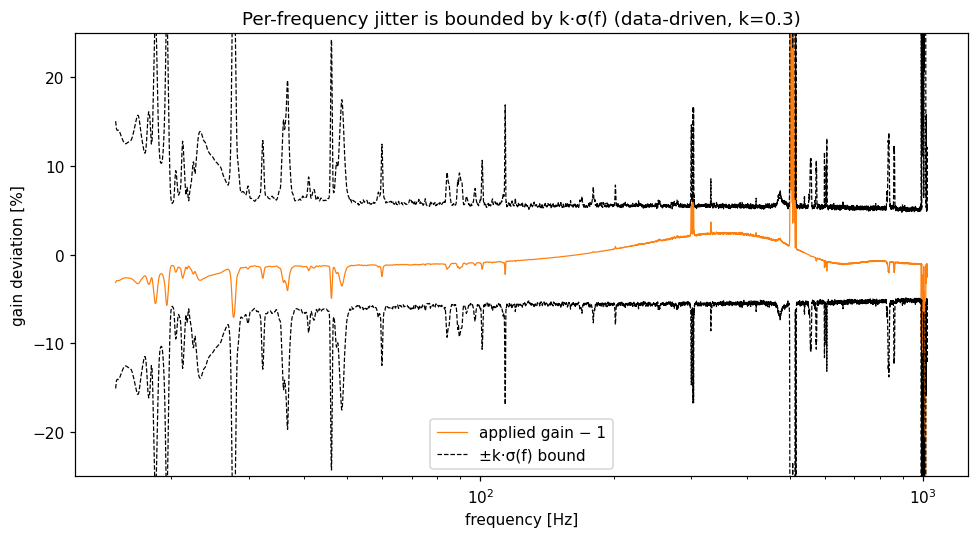

In [6]:
lo = np.percentile(sample, 5, axis=0); hi = np.percentile(sample, 95, axis=0)
plt.figure()
plt.fill_between(freq[band], lo[band], hi[band], color="C0", alpha=0.25,
                 label="real bank 5–95%")
plt.loglog(freq[band], base_asd[band], "k", lw=1.5, label="real ASD")
for i, a in enumerate(augs):
    plt.loglog(freq[band], a[band], "C1", lw=0.7, alpha=0.8, label="augmented" if i == 0 else None)
plt.xlabel("frequency [Hz]"); plt.ylabel(r"ASD [1/$\sqrt{\rm Hz}$]")
plt.title("Augmented ASDs remain within the real bank's 5–95% envelope (physical)")
plt.legend(); plt.tight_layout(); plt.show()

# residual: gain-1 vs the +-k*sigma bound
_, g = data_driven_augment(base_asd, sigma, np.random.default_rng(1), k=0.3)
plt.figure()
plt.semilogx(freq[band], 100*(g[band]-1), lw=0.8, color="C1", label="applied gain − 1")
plt.semilogx(freq[band],  100*0.3*sigma[band], "k--", lw=0.8, label="±k·σ(f) bound")
plt.semilogx(freq[band], -100*0.3*sigma[band], "k--", lw=0.8)
plt.xlabel("frequency [Hz]"); plt.ylabel("gain deviation [%]"); plt.ylim(-25, 25)
plt.title("Per-frequency jitter is bounded by k·σ(f) (data-driven, k=0.3)")
plt.legend(); plt.tight_layout(); plt.show()

## 5. How much does the data allow? — jitter-strength sweep

The jitter is capped at `k·σ(f)`. **`k = 1` makes the per-frequency jitter equal to the full
real spread σ(f)** — the physical ceiling; beyond it the ASD would leave the real bank
(extrapolation = unphysical). Below: k = 0.3 / 0.6 / 1.0, with the real 5–95% envelope shaded.
Even k = 1 looks modest because (a) ~18% is small on a log axis and (b) the recolour **swap**
between the 250k real ASDs already supplies that full diversity — the jitter just fills the
gaps between discrete samples.

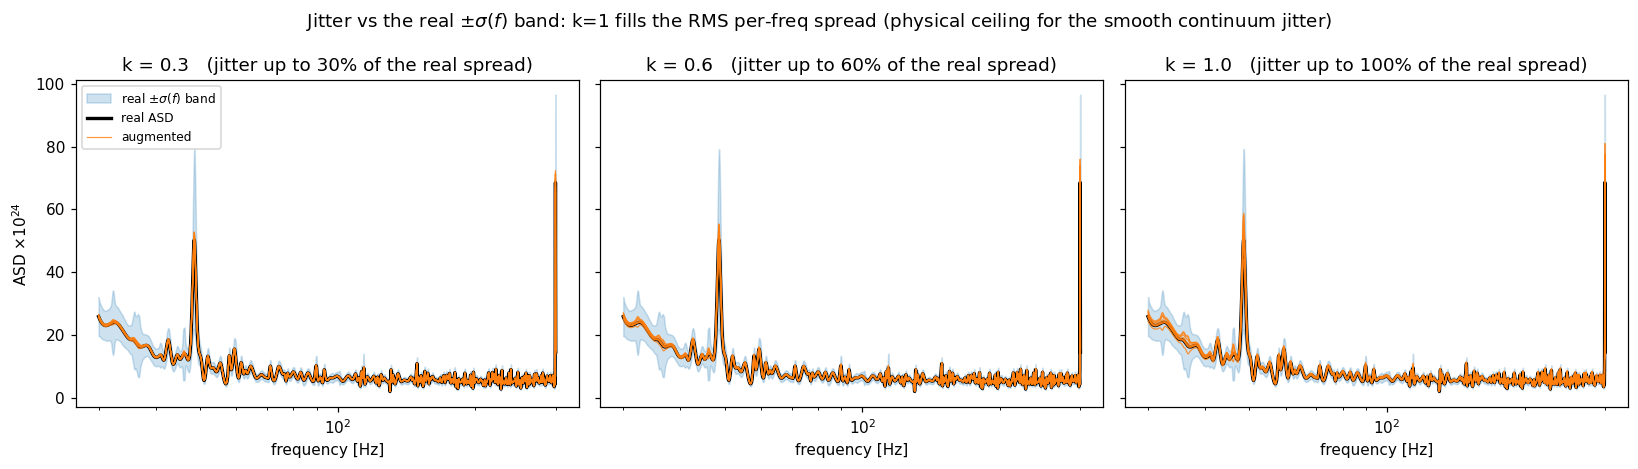

In [7]:
zb = (freq >= 30) & (freq <= 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
sig_band = np.clip(sigma, 0, 0.6)      # clamp only for the band viz (lines spike higher)
for ax, k in zip(axes, (0.3, 0.6, 1.0)):
    krng = np.random.default_rng(7)
    # FAIR reference: +-1 sigma(f) around THIS ASD (the real RMS per-freq spread),
    # not the whole-bank 5-95% (which is ~3.3 sigma and so looks ~1.6x wider).
    ax.fill_between(freq[zb], (base_asd*(1-sig_band))[zb]*1e24,
                    (base_asd*(1+sig_band))[zb]*1e24, color="C0", alpha=0.22,
                    label=r"real $\pm\sigma(f)$ band")
    ax.plot(freq[zb], base_asd[zb]*1e24, "k", lw=2.2, label="real ASD")
    for i in range(8):
        a = data_driven_augment(base_asd, sigma, krng, k=k)[0]
        ax.plot(freq[zb], a[zb]*1e24, "C1", lw=0.8, alpha=0.8,
                label="augmented" if i == 0 else None)
    ax.set_xscale("log"); ax.set_xlabel("frequency [Hz]")
    ax.set_title(f"k = {k}   (jitter up to {k*100:.0f}% of the real spread)")
axes[0].set_ylabel(r"ASD $\times 10^{24}$"); axes[0].legend(fontsize=8)
plt.suptitle(r"Jitter vs the real $\pm\sigma(f)$ band: k=1 fills the RMS per-freq spread (physical ceiling for the smooth continuum jitter)")
plt.tight_layout(); plt.show()

## Summary
- The real recolour ASD bank is genuinely diverse: continuum σ(f) ≈ 18%, plus wandering lines.
- The data-driven jitter caps the per-frequency perturbation to `k·σ(f)` (k=0.3), so it is
  **guaranteed a fraction of the real spread** — physical by construction, and naturally
  frequency-dependent (larger where the real noise varies more, tiny in the quiet band).
- Augmented ASDs stay inside the bank's 5–95% envelope.
- **Caveat that bit us:** compute σ(f) in **float64** — ASD² underflows float32.

Next: wire `k·σ(f)` (σ precomputed from the resident bank in float64) into
`RecolourPostprocess` to replace the fixed `dr_gain` bound.